# Lab 3: Curve Fitting in Neural Data

In this lab we:
1. Extract trial-based spike times from MT neurons.
2. Visualize responses with raster plots and PSTHs.
3. Summarize tuning across stimulus directions.
4. Fit tuning curves using parametric models:
   - Gaussian (linear / Cartesian tuning curves)
   - Von Mises (circular tuning curves)
5. Explore the effect of baseline subtraction.


Import libraries

In [1]:
import os
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from google.cloud import bigquery

/Users/sspivack/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Init client

In [2]:
%load_ext google.cloud.bigquery
client = bigquery.Client() 

Ingest data from BigQuery

In [3]:
%%bigquery mt
  select
    trial_id,
    (select array_agg(cast(x as float64)) from unnest(json_extract_array(spike_times)) as x) as spike_times,
    condition_id,
    condition_angle,
    unit_label
  from neural-ds-fe73.lab1_ephys.mt

Query is running:   0%|          |

Downloading:   0%|          |

In [4]:
mt

,trial_id,spike_times,condition_id,condition_angle,unit_label
0,4,"[1638.6, 1641.7, 1653.0, 1663.0, 1691.1, 1731....",0,0,"A588, U18, #15, OT"
1,16,"[516.3, 3126.0, 4076.1, 4103.7, 4125.8, 4215.2...",0,0,"A588, U18, #15, OT"
2,26,"[106.3, 115.1, 1353.7, 1438.2, 1555.4, 1580.5,...",0,0,"A588, U18, #15, OT"
3,46,"[449.8, 613.5, 642.5, 810.7, 1225.2, 1652.9, 1...",0,0,"A588, U18, #15, OT"
4,58,"[44.7, 98.1, 162.0, 740.3, 1839.4, 1881.5, 195...",0,0,"A588, U18, #15, OT"
...,...,...,...,...,...
175,133,"[140.9, 285.9, 2292.1, 3128.7, 3178.2, 4013.1,...",11,330,"A588, U18, #15, OT"
176,145,"[99.7, 120.9, 228.0, 269.0, 314.6, 349.9, 355....",11,330,"A588, U18, #15, OT"
177,157,"[145.6, 344.4, 3572.7, 3585.8, 3632.4, 3689.6,...",11,330,"A588, U18, #15, OT"
178,169,"[273.5, 1874.6, 3018.5, 3080.9, 3139.7, 4108.7...",11,330,"A588, U18, #15, OT"


Raster plot from a given stimulus condition of area MT

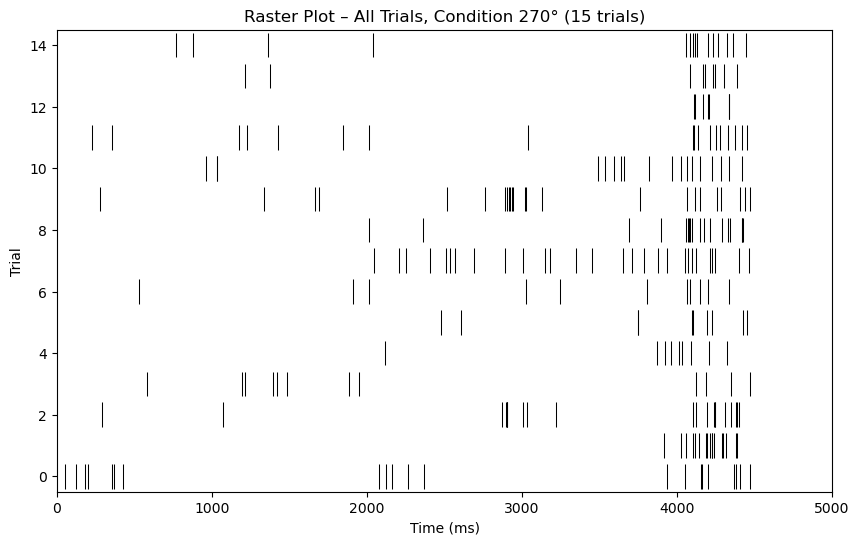

In [5]:
# --- Choose condition ---
chosen_angle = 270  # You can change this (0–330 in 30 degree steps)

# --- Filter trials with that condition_angle ---
subset = mt[mt["condition_angle"] == chosen_angle].reset_index(drop=True)

# --- Plot ---
plt.figure(figsize=(10, 6))
for i, row in subset.iterrows(): # iterrows gives us index and series for each iteration
    spikes = np.array(row["spike_times"]) # get array of spikes
    plt.vlines(spikes, i - 0.4, i + 0.4, color='black', linewidth=0.75) # plot vline with some buffer
plt.xlim(0, 5000)
plt.ylim(-0.5, len(subset) - 0.5)
plt.xlabel("Time (ms)")
plt.ylabel("Trial")
plt.title(f"Raster Plot – All Trials, Condition {chosen_angle}° ({len(subset)} trials)")
plt.show()


PSTH from a given stimulus condition of area MT

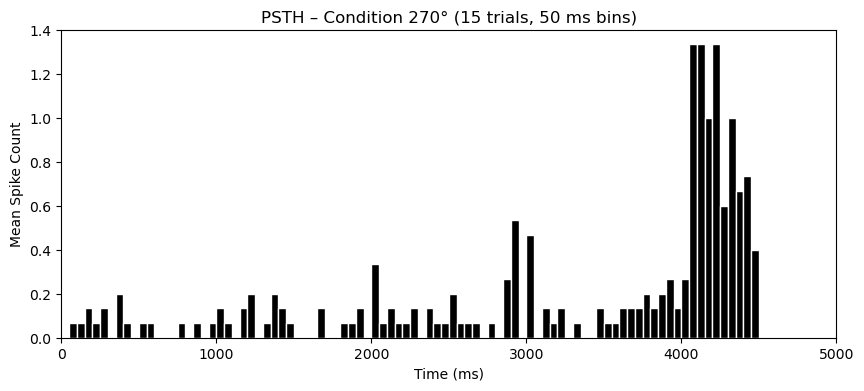

In [6]:
# --- Choose condition ---
chosen_angle = 270  # You can change this (0–330 in 30 degree steps)

# --- Filter trials ---
subset = mt[mt["condition_angle"] == chosen_angle].reset_index(drop=True)

# --- PSTH parameters ---
bin_size = 50  # in ms
time_range = (0, 5000) # 0 to 5000ms
bins = np.arange(time_range[0], time_range[1] + bin_size, bin_size) # array of bin values
bin_centers = bins[:-1] + bin_size / 2 # corresponding bin centers (take left edge per bin -> shift by half bin)

# --- Compute histogram per trial ---
spike_matrix = [] # init empty list
for _, row in subset.iterrows(): # ignore index, keep row
    spikes = np.array(row["spike_times"]) # extract spikes as array
    spikes = spikes[(spikes >= time_range[0]) & (spikes <= time_range[1])] # restrict to time window
    counts, _ = np.histogram(spikes, bins=bins) # count spikes per bin for this trial
    spike_matrix.append(counts) # append to list

spike_matrix = np.array(spike_matrix)  # shape: (n_trials, n_bins)
mean_psth = spike_matrix.mean(axis=0) # average downs rows [ axis=0 (rows/trials); axis=1 (colums/bins) ]

# --- Plot PSTH ---
plt.figure(figsize=(10, 4))
plt.bar(bin_centers, mean_psth, width=bin_size, color='black', edgecolor='white') 

plt.xlim(time_range)
plt.xlabel("Time (ms)")
plt.ylabel("Mean Spike Count")
plt.title(f"PSTH – Condition {chosen_angle}° ({len(subset)} trials, {bin_size} ms bins)")
plt.show()


### Fitting with `scipy.optimize.curve_fit`

`scipy.optimize.curve_fit` solves a **nonlinear least squares** problem.  
Given data points \((x_i, y_i)\) and a model function \(f(x; \theta)\) with parameters \(\theta\), it finds:

$$
\hat{\theta} = \arg \min_{\theta} \sum_{i=1}^n \big( y_i - f(x_i; \theta) \big)^2
$$

That is, it adjusts parameters so the model curve is as close as possible to the observed data in a least-squares sense.

---

#### Output
- **`params`** : the best-fit parameters $\hat{\theta}$.  
- **`covariance`** : an approximate covariance matrix of the fitted parameters, computed from the Jacobian of residuals.  
  - Diagonal entries give parameter variances.  
  - Standard error of parameter $j$ is $\sqrt{\text{cov}[j,j]}$.

---

#### Example
```python
from scipy.optimize import curve_fit
import numpy as np

# Gaussian model
def gaussian(x, a, b, c, d):
    return a * np.exp(-(x - b)**2 / (2*c**2)) + d

# initial guess
p0 = [amp_guess, mean_guess, sigma_guess, offset_guess]

# fit
params, cov = curve_fit(gaussian, xdata, ydata, p0=p0)


Gaussian fit (cartesian)

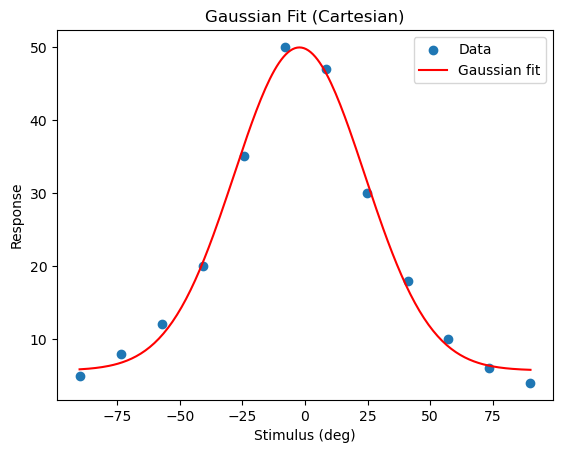

In [7]:
# Example data
x = np.linspace(-90, 90, 12)  # stimulus positions
y = np.array([5, 8, 12, 20, 35, 50, 47, 30, 18, 10, 6, 4])

# Gaussian model
def gaussian(x, a, b, c, d):
    return a * np.exp(-(x - b)**2 / (2 * c**2)) + d

# Initial guesses: [amplitude, mean, sigma, baseline]
p0 = [y.max() - y.min(), np.mean(x), 20, y.min()]

params, _ = curve_fit(gaussian, x, y, p0=p0)

# Plot
plt.scatter(x, y, label='Data')
x_fine = np.linspace(x.min(), x.max(), 200)
plt.plot(x_fine, gaussian(x_fine, *params), 'r-', label='Gaussian fit')
plt.xlabel('Stimulus (deg)')
plt.ylabel('Response')
plt.title('Gaussian Fit (Cartesian)')
plt.legend()
plt.show()

## Baseline subtraction

We measure spike rates during:

- **Active window:** \([start\_ms, stop\_ms]\)  
- **Baseline window:** \([baseline\_start, baseline\_stop]\)  

The baseline-subtracted rate is defined as:

$$
r_{\text{sub}}(\theta) \;=\; r_{\text{active}}(\theta) \;-\; r_{\text{baseline}}(\theta)
$$

- If the baseline window is set to \((0,0)\), subtraction is skipped.  
- This isolates the modulation due to the stimulus.


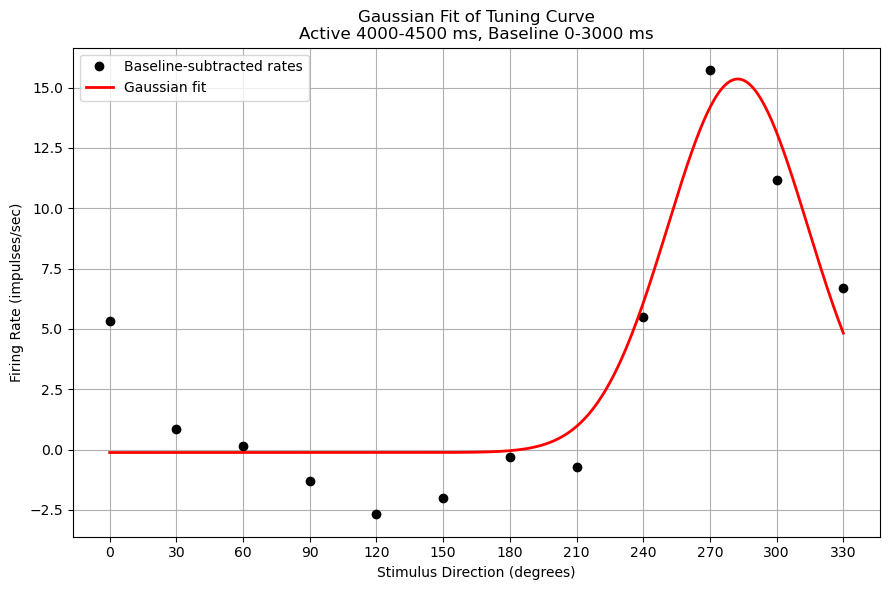

Amplitude (a): 15.48
Preferred direction (b): 282.5°
Width (c, sigma): 31.43
Offset (d): -0.12


In [8]:
# --- Define windows ---
condition_angles = np.arange(0, 360, 30)  # stimulus directions
start_ms, stop_ms = 4000, 4500            # active window
baseline_start, baseline_stop = 0, 3000   # baseline window (set both = 0 for no baseline subtraction)

trial_duration_s = (stop_ms - start_ms) / 1000.0
baseline_duration_s = (baseline_stop - baseline_start) / 1000.0 if baseline_stop > baseline_start else None

# --- Compute mean firing rate per condition (active window) ---
mean_rates = []
baseline_rates = []

for angle in condition_angles:
    subset = mt[mt["condition_angle"] == angle].reset_index(drop=True)
    total_spikes, total_baseline_spikes = 0, 0

    for _, row in subset.iterrows():
        spikes = np.array(row["spike_times"])

        # Active window spikes
        active = spikes[(spikes >= start_ms) & (spikes <= stop_ms)]
        total_spikes += len(active)

        # Baseline window spikes
        if baseline_duration_s:
            baseline_sp = spikes[(spikes >= baseline_start) & (spikes <= baseline_stop)]
            total_baseline_spikes += len(baseline_sp)

    n_trials = len(subset)
    if n_trials > 0:
        mean_rate = total_spikes / n_trials / trial_duration_s
        if baseline_duration_s:
            baseline_rate = total_baseline_spikes / n_trials / baseline_duration_s
        else:
            baseline_rate = 0
    else:
        mean_rate, baseline_rate = 0, 0

    mean_rates.append(mean_rate)
    baseline_rates.append(baseline_rate)

mean_rates = np.array(mean_rates)
baseline_rates = np.array(baseline_rates)

# --- Subtract baseline (per angle) ---
mean_rates_sub = mean_rates - baseline_rates

# --- Gaussian model ---
def gaussian(x, a, b, c, d):
    return a * np.exp(-(x - b)**2 / (2 * c**2)) + d

# Initial guesses
p0 = [mean_rates_sub.max() - mean_rates_sub.min(),
      condition_angles[np.argmax(mean_rates_sub)],
      40,
      mean_rates_sub.min()]

# Fit single Gaussian
params, _ = curve_fit(gaussian, condition_angles, mean_rates_sub, p0=p0)

# --- Plot ---
x_fine = np.linspace(condition_angles.min(), condition_angles.max(), 400)

plt.figure(figsize=(9, 6))
plt.plot(condition_angles, mean_rates_sub, 'ko', label='Baseline-subtracted rates')
plt.plot(x_fine, gaussian(x_fine, *params), 'r-', lw=2, label='Gaussian fit')
plt.xticks(condition_angles)
plt.xlabel("Stimulus Direction (degrees)")
plt.ylabel("Firing Rate (impulses/sec)")
plt.title(f"Gaussian Fit of Tuning Curve\nActive {start_ms}-{stop_ms} ms, Baseline {baseline_start}-{baseline_stop} ms")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print fit parameters
a, b, c, d = params
print(f"Amplitude (a): {a:.2f}")
print(f"Preferred direction (b): {b:.1f}°")
print(f"Width (c, sigma): {c:.2f}")
print(f"Offset (d): {d:.2f}")


circular gaussian (von Mises)

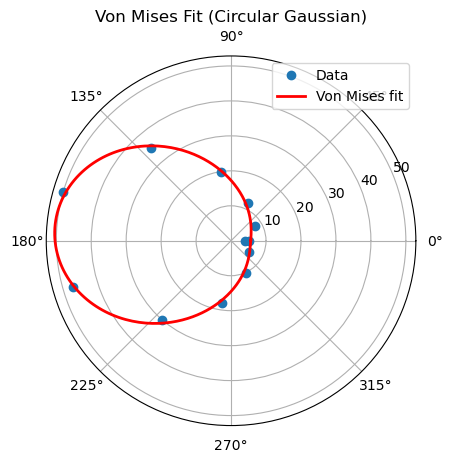

In [9]:
# Example data
theta = np.linspace(0, 2*np.pi, 12)  # stimulus directions (radians)
y = np.array([5, 8, 12, 20, 35, 50, 47, 30, 18, 10, 6, 4])

# Von Mises function
def von_mises(theta, A, kappa, mu, B):
    return A * np.exp(kappa * np.cos(theta - mu)) + B

# Initial guesses: [amplitude, concentration, mean angle, baseline]
p0 = [y.max() - y.min(), 1, np.mean(theta), y.min()]

params, _ = curve_fit(von_mises, theta, y, p0=p0)

# Plot
theta_fine = np.linspace(0, 2*np.pi, 300)
y_fit = von_mises(theta_fine, *params)

ax = plt.subplot(111, polar=True)
ax.plot(theta, y, 'o', label='Data')
ax.plot(theta_fine, y_fit, 'r-', linewidth=2, label='Von Mises fit')
ax.set_title('Von Mises Fit (Circular Gaussian)')
ax.legend()
plt.show()

# The point is to extract the parameters


Fitted parameters (baseline-subtracted):
Amplitude (A): -43605.64
Concentration (kappa): 0.00
Preferred angle (mu, deg): 116.8
Baseline (B): 43608.84


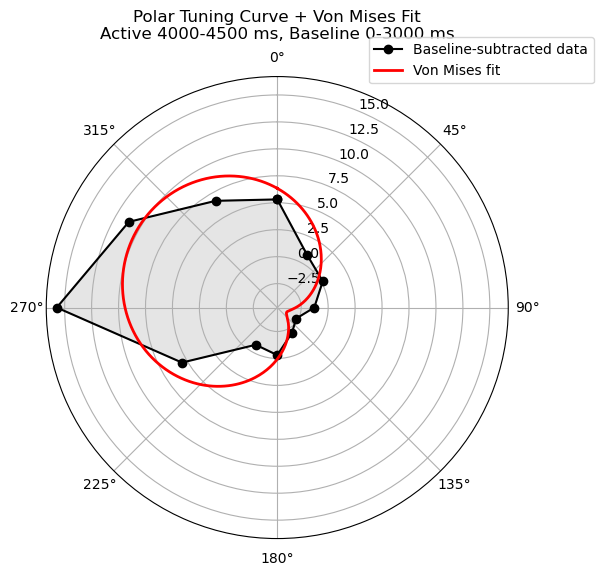

In [10]:
# --- Define windows ---
condition_angles = np.arange(0, 360, 30)  # stimulus directions
start_ms, stop_ms = 4000, 4500            # active window
baseline_start, baseline_stop = 0, 3000   # baseline window (set both=0 for no subtraction)

trial_duration_s = (stop_ms - start_ms) / 1000.0
baseline_duration_s = (baseline_stop - baseline_start) / 1000.0 if baseline_stop > baseline_start else None

# --- Compute mean firing rate per condition ---
mean_rates, baseline_rates = [], []

for angle in condition_angles:
    subset = mt[mt["condition_angle"] == angle].reset_index(drop=True)
    total_spikes, total_baseline_spikes = 0, 0

    for _, row in subset.iterrows():
        spikes = np.array(row["spike_times"])

        # Active window
        active = spikes[(spikes >= start_ms) & (spikes <= stop_ms)]
        total_spikes += len(active)

        # Baseline window
        if baseline_duration_s:
            base = spikes[(spikes >= baseline_start) & (spikes <= baseline_stop)]
            total_baseline_spikes += len(base)

    n_trials = len(subset)
    if n_trials > 0:
        mean_rate = total_spikes / n_trials / trial_duration_s
        baseline_rate = total_baseline_spikes / n_trials / baseline_duration_s if baseline_duration_s else 0
    else:
        mean_rate, baseline_rate = 0, 0

    mean_rates.append(mean_rate)
    baseline_rates.append(baseline_rate)

mean_rates = np.array(mean_rates)
baseline_rates = np.array(baseline_rates)

# --- Subtract baseline (per condition) ---
mean_rates_sub = mean_rates - baseline_rates

# --- Convert to radians and close circle ---
theta = np.deg2rad(np.append(condition_angles, condition_angles[0]))
r = np.append(mean_rates_sub, mean_rates_sub[0])

# --- Von Mises function ---
def von_mises(theta, A, kappa, mu, B):
    return A * np.exp(kappa * np.cos(theta - mu)) + B

# --- Fit Von Mises to baseline-subtracted data ---
theta_data = np.deg2rad(condition_angles)
r_data = mean_rates_sub

p0 = [r_data.max() - r_data.min(), 1, np.mean(theta_data), r_data.min()]
params, _ = curve_fit(von_mises, theta_data, r_data, p0=p0)

# Extract fitted parameters
A_fit, kappa_fit, mu_fit, B_fit = params
print("Fitted parameters (baseline-subtracted):")
print(f"Amplitude (A): {A_fit:.2f}")
print(f"Concentration (kappa): {kappa_fit:.2f}")
print(f"Preferred angle (mu, deg): {np.rad2deg(mu_fit):.1f}")
print(f"Baseline (B): {B_fit:.2f}")

# --- Evaluate fit ---
theta_fine = np.linspace(0, 2*np.pi, 400)
r_fit = von_mises(theta_fine, *params)

# --- Plot polar tuning curve with fit ---
plt.figure(figsize=(6, 6))
ax = plt.subplot(111, polar=True)
ax.plot(theta, r, 'ko-', label='Baseline-subtracted data')
ax.plot(theta_fine, r_fit, 'r-', linewidth=2, label='Von Mises fit')
ax.fill(theta, r, color='black', alpha=0.1)

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_title(f"Polar Tuning Curve + Von Mises Fit\nActive {start_ms}-{stop_ms} ms, Baseline {baseline_start}-{baseline_stop} ms", va='bottom')
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.show()
